## 데이터 이해

In [1]:
import pandas as pd
import numpy as np


## Train dataset, Test dataset 불러오기

In [2]:
# 1. 데이터 불러오기 및 데이터 확인
df= pd.read_csv("C:\\Users\\채재헌\\OneDrive - 계명대학교\\바탕 화면\Research\\data\\raw_data\\train\\Training_Data.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\채재헌\AppData\Local\Temp\ipykernel_31392\2134028140.py:2: SyntaxWarning: invalid escape sequence '\R'
  df= pd.read_csv("C:\\Users\\채재헌\\OneDrive - 계명대학교\\바탕 화면\Research\\data\\raw_data\\train\\Training_Data.csv")


,PageNo,Speed,Length,RealPower,SetFrequency,SetDuty,SetPower,GateOnTime,WorkingTime
0,1,250,241.1,1688,1000,100,82,1154,2022-01-08 10:11:45.181
1,2,250,241.2,1713,1000,100,83,1670,2022-01-08 10:11:48.487
2,3,250,241.1,1695,1000,100,82,1153,2022-01-08 10:11:51.245
3,4,250,241.2,1717,1000,100,83,1670,2022-01-08 10:11:54.493
4,5,250,241.1,1698,1000,100,82,1154,2022-01-08 10:11:57.269


### 모든 CSV 컬럼명에 앞뒤 공백 제거

In [3]:
import pandas as pd
from pathlib import Path

data_dir = Path(r"c:\Users\채재헌\OneDrive - 계명대학교\바탕 화면\Research\data")

for csv_path in sorted(data_dir.rglob("*.csv")):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    df.to_csv(csv_path, index=False)
    print("Updated:", csv_path.name, "->", list(df.columns))

Updated: label_summary.csv -> ['Split', 'File', 'Rows', 'Normal', 'Anomaly']
Updated: Test_Data_labeled.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime', 'label']
Updated: WeldingTest_01_OK_labeled.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime', 'label']
Updated: WeldingTest_02_OK_labeled.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime', 'label']
Updated: WeldingTest_03_NG_Label.csv -> ['Unnamed: 0', 'label']
Updated: WeldingTest_03_NG_labeled.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime', 'label']
Updated: WeldingTest_04_NG_Label.csv -> ['Unnamed: 0', 'label']
Updated: WeldingTest_04_NG_labeled.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime', 'l

### WorkingTime 문자열 형태의 속성을 datetime으로 변환하고 순서 정보로 정리

In [4]:
for csv_path in sorted(data_dir.rglob("*.csv")):
    df = pd.read_csv(csv_path)

    if "WorkingTime" in df.columns:
        # 문자열 타임스탬프를 datetime으로 변환
        df["WorkingTime"] = pd.to_datetime(
            df["WorkingTime"].astype(str).str.strip(),
            errors="coerce"
        )

        # 순서 정보 추가
        df["ElapsedSeconds"] = (df["WorkingTime"] - df["WorkingTime"].min()).dt.total_seconds()
        df["Sequence"] = range(1, len(df) + 1)


### NG 라벨 병합

In [5]:
base_dir = Path(r"c:\Users\채재헌\OneDrive - 계명대학교\바탕 화면\Research")
raw_dir = base_dir / "data" / "raw_data" / "test"
label_dir = base_dir / "data" / "preprocessed" / "test"

for test_name in ["WeldingTest_03_NG", "WeldingTest_04_NG"]:
    raw_path = raw_dir / f"{test_name}.csv"
    label_path = label_dir / f"{test_name}_Label.csv"

    df_raw = pd.read_csv(raw_path)
    df_label = pd.read_csv(label_path)

    # 라벨 파일에 Unnamed: 0 컬럼이 있을 경우 제거
    if "Unnamed: 0" in df_label.columns:
        df_label = df_label.drop(columns=["Unnamed: 0"])

    if len(df_raw) != len(df_label):
        raise ValueError(f"Row count mismatch: {raw_path.name} {len(df_raw)} vs {label_path.name} {len(df_label)}")

    df_merged = pd.concat([df_raw.reset_index(drop=True), df_label.reset_index(drop=True)], axis=1)
    out_path = raw_dir / f"{test_name}_labeled.csv"
    df_merged.to_csv(out_path, index=False)

    print(f"Merged {raw_path.name} + {label_path.name} -> {out_path.name}")

Merged WeldingTest_03_NG.csv + WeldingTest_03_NG_Label.csv -> WeldingTest_03_NG_labeled.csv
Merged WeldingTest_04_NG.csv + WeldingTest_04_NG_Label.csv -> WeldingTest_04_NG_labeled.csv


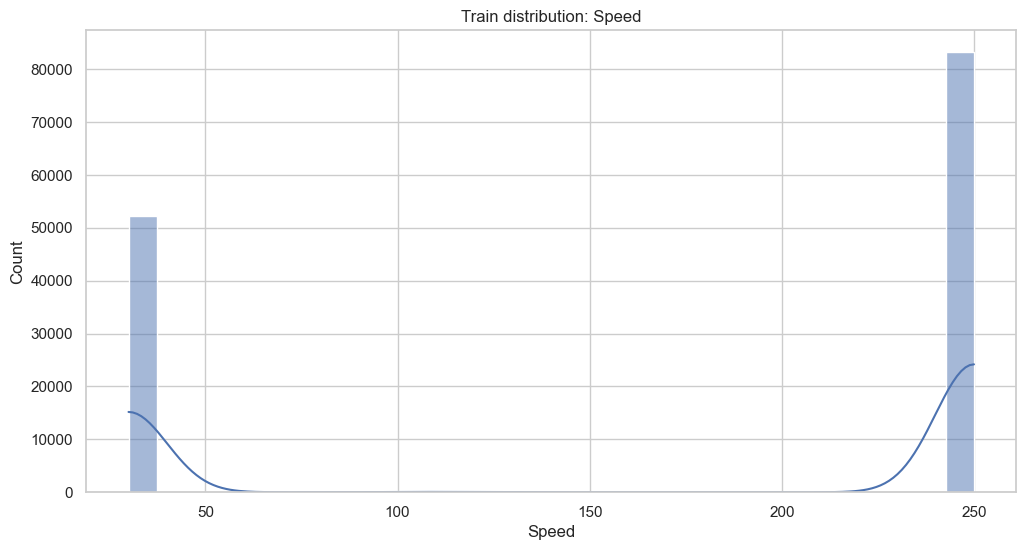

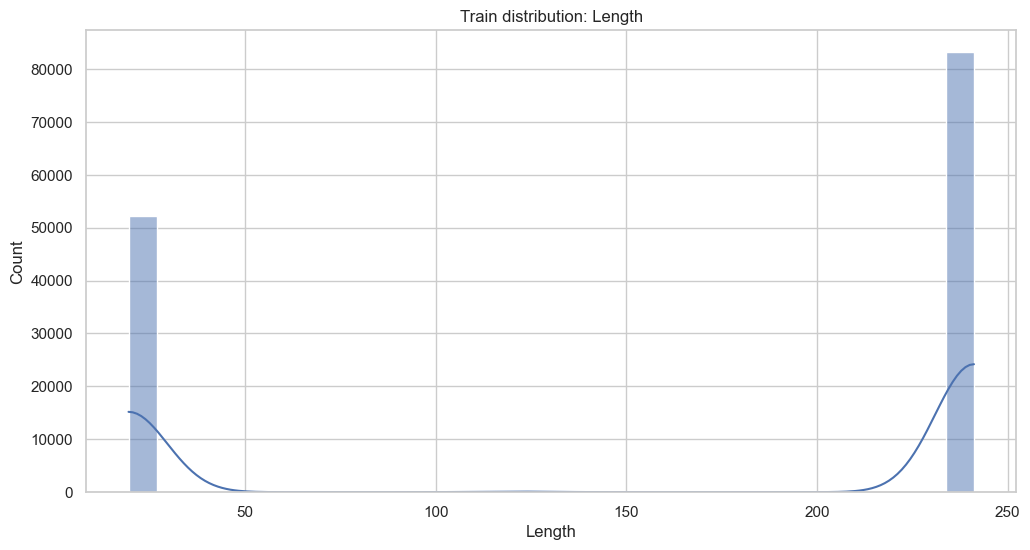

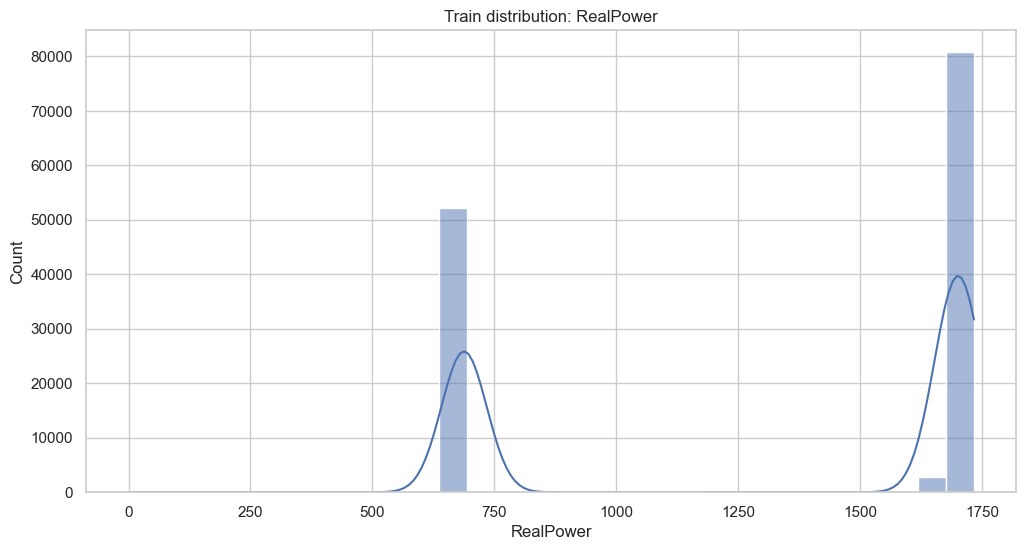

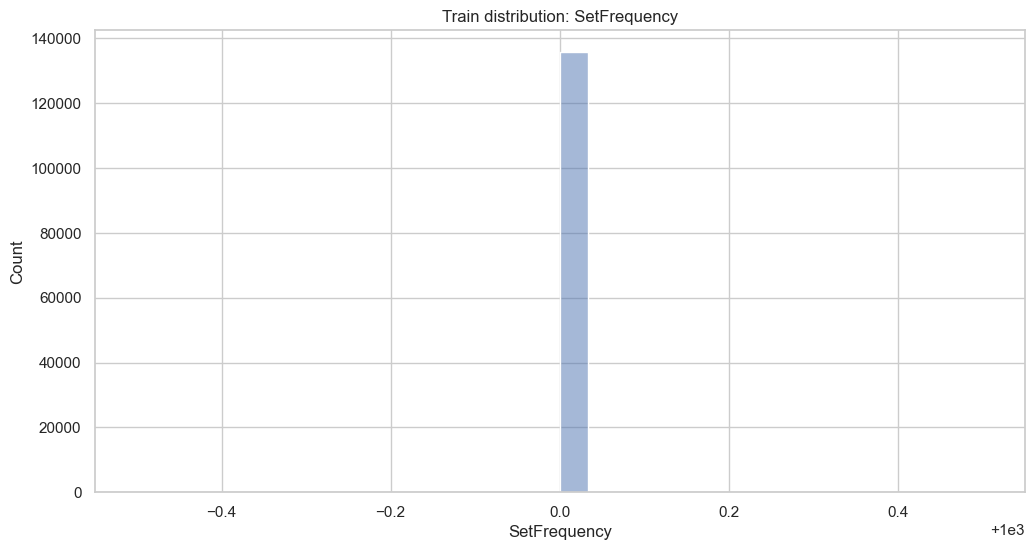

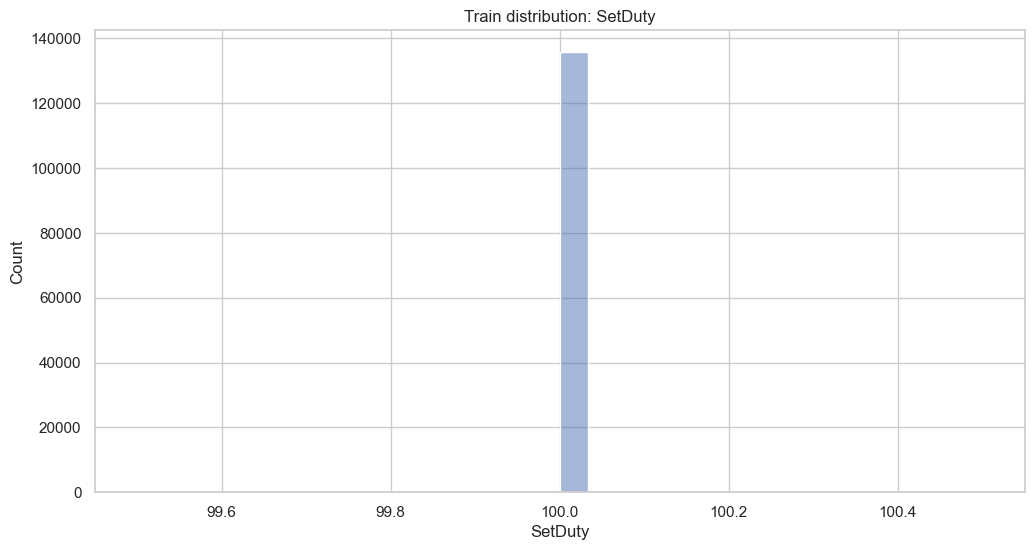

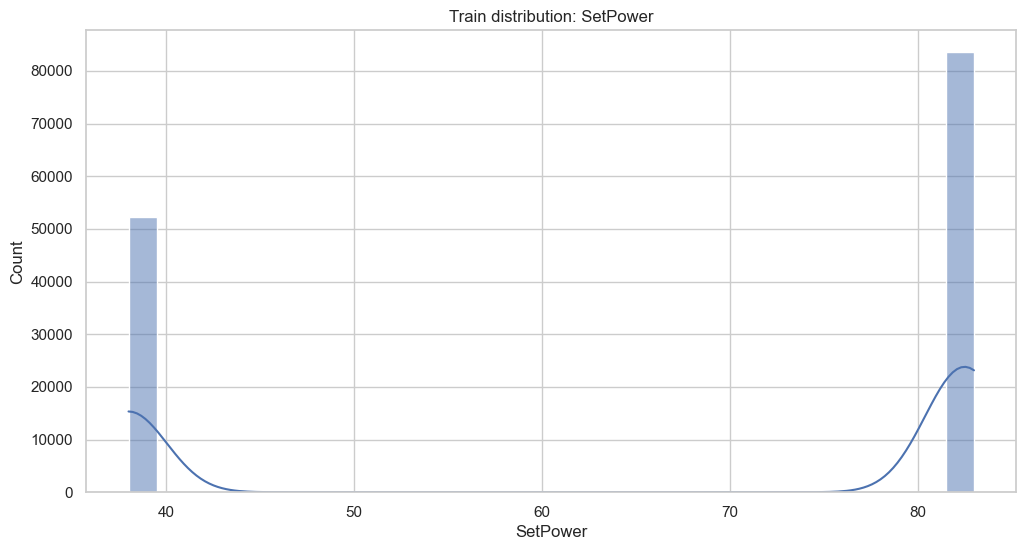

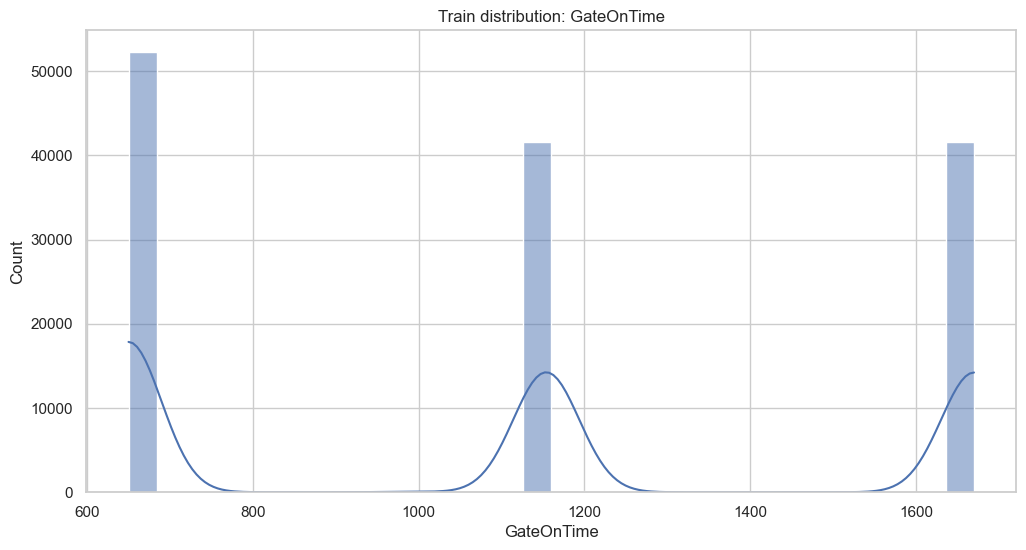

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
sns.set(style="whitegrid")

base = Path(r"c:\Users\채재헌\OneDrive - 계명대학교\바탕 화면\Research")
raw = base / "data" / "raw_data"

train = pd.read_csv(raw / "train" / "Training_Data.csv", parse_dates=["WorkingTime"])
ng3 = pd.read_csv(raw / "test" / "WeldingTest_03_NG_labeled.csv", parse_dates=["WorkingTime"])
ng4 = pd.read_csv(raw / "test" / "WeldingTest_04_NG_labeled.csv", parse_dates=["WorkingTime"])

features = ["Speed", "Length", "RealPower", "SetFrequency", "SetDuty", "SetPower", "GateOnTime"]

# 1) 변수 분포
for col in features:
    plt.figure()
    sns.histplot(train[col], kde=True, bins=30)
    plt.title(f"Train distribution: {col}")
    plt.show()



1. Train distribution 그래프들

- Speed, Length, SetPower,RealPower는 두 개 정도의 뚜렷한 군집으로 나뉩니다.

Speed: 주로 30 또는 250
Length: 주로 19.4 또는 241.1~241.2
SetPower: 주로 38 또는 82~83

RealPower
- 낮은 출력: 약 680~700
- 높은 출력: 약 1680~1730

=> 즉 연속적으로 다양한 조건에서 용접한 데이터라기보다는, 정해진 공정 조건 몇 가지가 반복된 데이터

 

----

SetFrequency와 SetDuty는 각각 전부 같은 값

SetFrequency = 1000
SetDuty = 100
그래서 이 두 변수는 값이 변하지 않기 때문에 모델 학습이나 이상 탐지에 거의 도움이 안돰.

---


GateOnTime은 세 구간으로 나뉩니다.

650
1154
1670
이것도 공정 조건/레시피별 설정값처럼 보입니다.


---





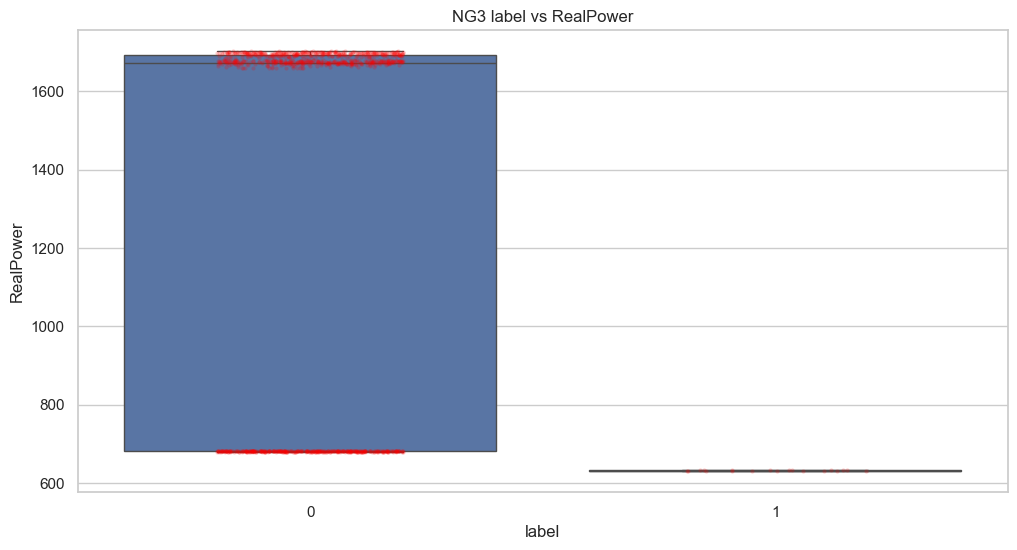

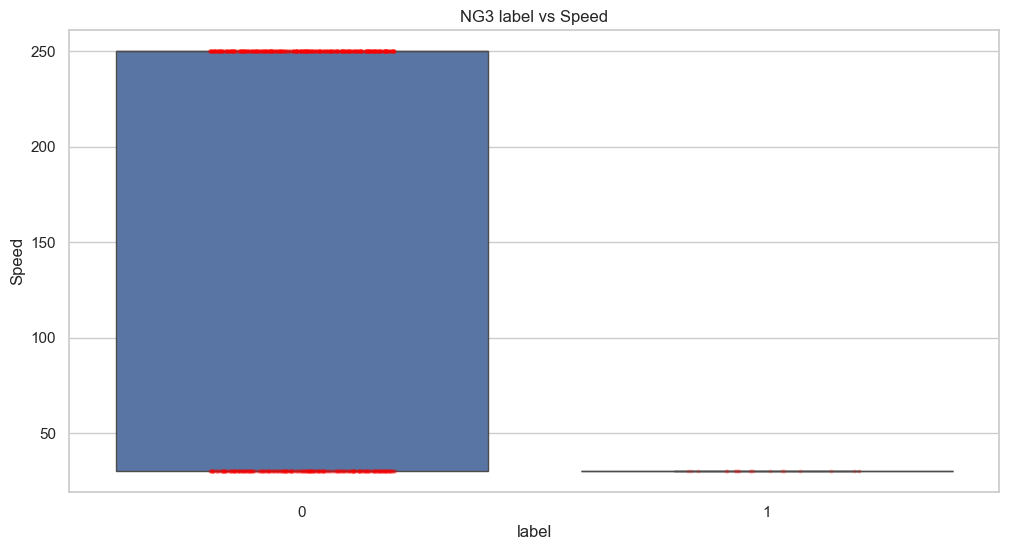

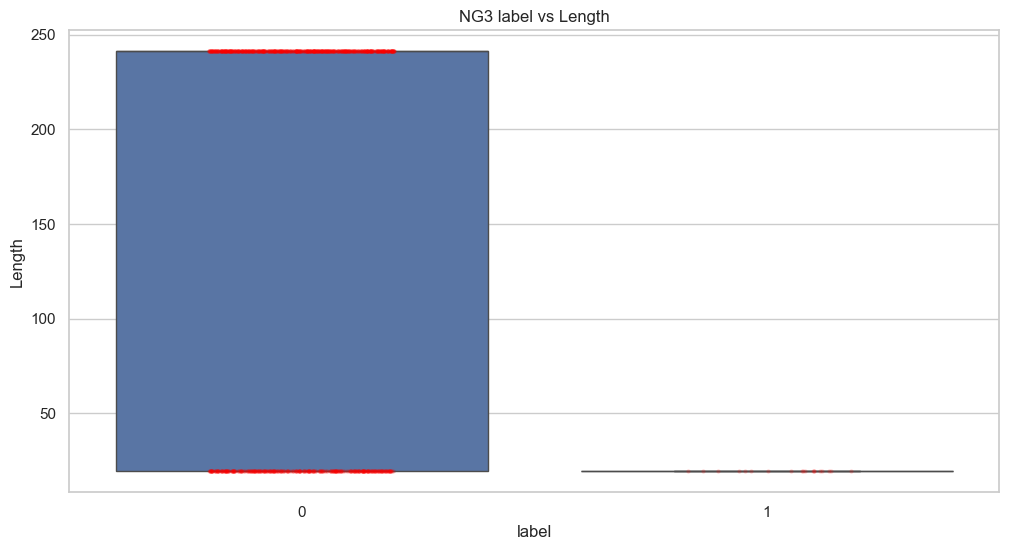

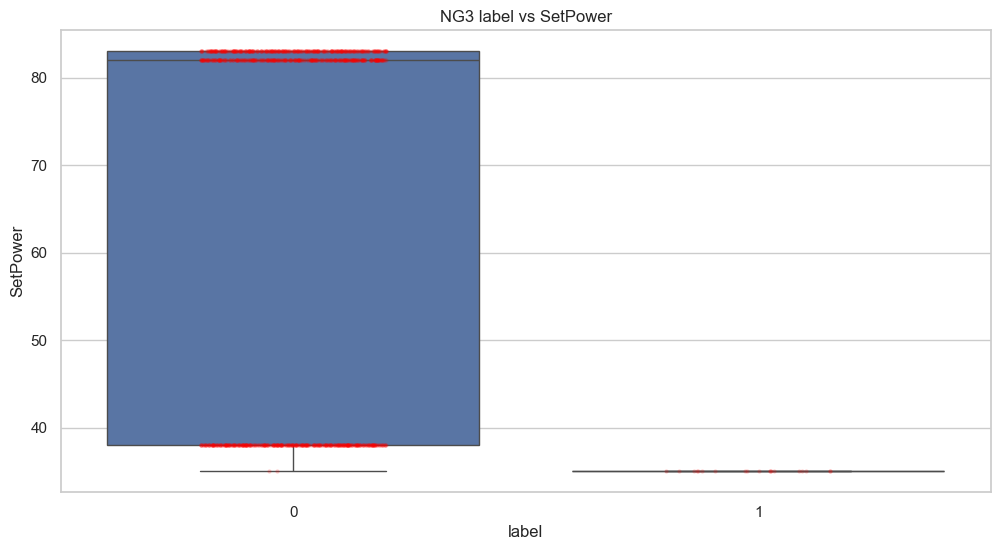

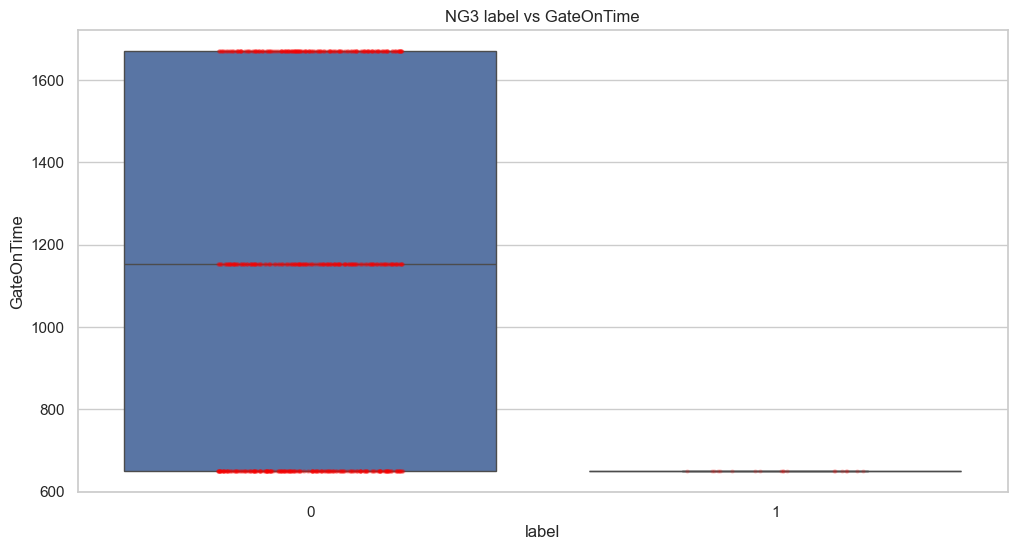

In [7]:

# 2) 정상 vs NG 비교 (NG3)
plt.figure()
sns.boxplot(x="label", y="RealPower", data=ng3, showfliers=False)
sns.stripplot(x="label", y="RealPower", data=ng3, color="red", alpha=0.2, jitter=0.2, size=3)
plt.title("NG3 label vs RealPower")
plt.show()

plt.figure()
sns.boxplot(x="label", y="Speed", data=ng3, showfliers=False)
sns.stripplot(x="label", y="Speed", data=ng3, color="red", alpha=0.2, jitter=0.2, size=3)
plt.title("NG3 label vs Speed")
plt.show()


plt.figure()
sns.boxplot(x="label", y="Length", data=ng3, showfliers=False)
sns.stripplot(x="label", y="Length", data=ng3, color="red", alpha=0.2, jitter=0.2, size=3)
plt.title("NG3 label vs Length")
plt.show()

plt.figure()
sns.boxplot(x="label", y="SetPower", data=ng3, showfliers=False)
sns.stripplot(x="label", y="SetPower", data=ng3, color="red", alpha=0.2, jitter=0.2, size=3)
plt.title("NG3 label vs SetPower")
plt.show()


plt.figure()
sns.boxplot(x="label", y="GateOnTime", data=ng3, showfliers=False)
sns.stripplot(x="label", y="GateOnTime", data=ng3, color="red", alpha=0.2, jitter=0.2, size=3)
plt.title("NG3 label vs GateOnTime")
plt.show()


 <변수별 해석>

RealPower
가장 눈에 띄는 변수입니다. label=1은 약 630~632 근처에 매우 좁게 몰려 있고, label=0은 약 680대와 1600~1700대까지 넓게 분포합니다.
따라서 NG3 이상 라벨은 실제 출력이 낮게 떨어지는 현상과 강하게 관련됩니다.

Speed
label=1은 전부 30에 고정되어 있습니다. 하지만 label=0에도 Speed=30인 데이터가 있기 때문에, Speed=30만으로 NG라고 판단할 수는 없습니다.
즉 Speed는 이상 발생 조건 중 하나지만, 단독 판별력은 RealPower보다 약합니다.

Length
label=1은 전부 19.4에 고정되어 있습니다. Speed와 비슷하게, 짧은 작업 길이 조건에서 NG가 발생한 것으로 보입니다.
다만 label=0에도 Length=19.4가 있으므로, 이것도 단독 원인이라기보다는 공정 조건 변수로 보는 게 좋습니다.

SetPower
label=1은 전부 35에 고정되어 있습니다. label=0은 35, 38, 82, 83 등이 섞여 있습니다.
이상 구간이 낮은 설정 출력 조건에 몰려 있으므로, NG3에서는 낮은 SetPower 조건이 이상과 관련 있어 보입니다.

GateOnTime
label=1은 전부 650에 고정되어 있습니다. label=0은 650, 1154, 1670 등 여러 조건이 있습니다.
즉 NG3의 이상은 짧은 GateOnTime 조건에서 발생했습니다.

SetFrequency
값이 전부 1000으로 고정되어 있어서 라벨 구분에 도움이 되지 않습니다.

SetDuty
값이 전부 100으로 고정되어 있어서 역시 라벨 구분에 도움이 되지 않습니다.

결론

NG3의 이상 라벨은 특정 레시피 조건에서 발생한 것으로 보입니다. 특히 RealPower가 약 630 근처로 낮게 형성되는 점이 가장 강한 이상 신호입니다.
다만 주의할 점은, Speed=30, Length=19.4, GateOnTime=650 같은 조건은 정상 데이터에도 존재합니다. 그래서 “이 조건이면 무조건 NG”가 아니라, 저속/짧은 길이/낮은 설정 출력 조건에서 RealPower가 비정상적으로 낮게 나타나는 패턴이 NG3의 핵심 특징이라고 보는 게 가장 타당합니다

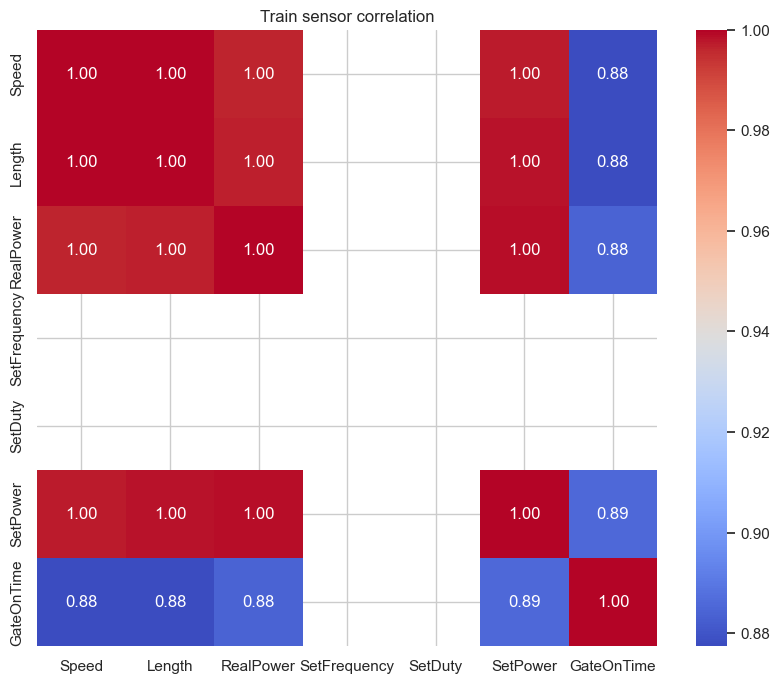

In [8]:

# 3) 상관관계 히트맵
corr = train[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Train sensor correlation")
plt.show()


Speed, Length, RealPower, SetPower는 거의 1.00에 가까운 강한 양의 상관관계를 보입니다.

이 말은 네 변수가 독립적으로 움직이는 게 아니라, 같은 공정 레시피에 따라 같이 바뀐다는 뜻입니다.

가장 직접적인 구분 변수: RealPower
공정 조건을 설명하는 변수: Speed, Length, SetPower, GateOnTime
정보가 거의 없는 변수: SetFrequency, SetDuty

주의할 점:

상관관계가 너무 높아서 모델에 모두 넣으면 중복 정보가 많을 수 있음
Speed, , SetPower, RealPower 중 일부만으로도 비슷한 정보를 설명할 가능성이 큼
SetFrequency, SetDuty는 값이 고정이라 상관계산에서도 실질적 의미가 없음
GateOnTime도 다른 변수들과 약 0.88~0.89 정도의 높은 상관관계가 있습니다. 이것 역시 공정 조건과 함께 설정되는 값으로 보입니다.


<!-- codex_preprocessing_pipeline_ws30 -->

## ?? ??? ??: WorkingTime ??, ?? ??, ?? ?? ??, ??? ??? ??

?? ??? ?? ??? ??? ??? ?? ??? ???? ?? ??? ????.

- `WorkingTime` ???? train ???? ??? ??
- ??/?? ?? ??: ?? `0`, ?? `1`
- ?? ?? ??: `RealPower`, `GateOnTime`, `SetPower`, `Speed`, `Length`
- ??? ??? ??: `window_size=30`, `stride=1`
- ??? ??: ??? ??? ?? ??? ???? ??? `1`

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "raw_data":
    ROOT = ROOT.parents[1]
elif ROOT.name == "data":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw_data"
PREPROCESSED_DIR = ROOT / "data" / "preprocessed"
WINDOWED_DIR = ROOT / "data" / "windowed"

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
(PREPROCESSED_DIR / "train").mkdir(parents=True, exist_ok=True)
(PREPROCESSED_DIR / "test").mkdir(parents=True, exist_ok=True)
WINDOWED_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ["RealPower", "GateOnTime", "SetPower", "Speed", "Length"]
WINDOW_SIZE = 30
STRIDE = 1

### 1. `WorkingTime` ?? train ??? ??

train ????? ?? ??? ?? ??? ?? `WorkingTime` ?? ?????? ????.

In [10]:
train_raw_path = RAW_DIR / "train" / "Training_Data.csv"
train_raw = pd.read_csv(train_raw_path)
train_raw["WorkingTime"] = train_raw["WorkingTime"].astype(str).str.strip()
train_raw["WorkingTime_dt"] = pd.to_datetime(train_raw["WorkingTime"])

train_sorted = (
    train_raw
    .sort_values("WorkingTime_dt")
    .drop(columns="WorkingTime_dt")
    .reset_index(drop=True)
)

# ?? train ??? WorkingTime ?? ?? ??? ???.
train_sorted.to_csv(train_raw_path, index=False)

is_sorted = pd.to_datetime(train_sorted["WorkingTime"]).is_monotonic_increasing
print(f"Train rows: {len(train_sorted):,}")
print(f"WorkingTime sorted: {is_sorted}")
print(f"First time: {train_sorted['WorkingTime'].iloc[0]}")
print(f"Last time: {train_sorted['WorkingTime'].iloc[-1]}")

Train rows: 135,759
WorkingTime sorted: True
First time: 2022-01-08 10:11:45.181
Last time: 2022-07-29 17:25:16.311


### 2. ??/?? ?? ??

?? ??? ???? ????.

- ??: `0`
- ??: `1`

train ???? ?? ???? ?? ?? ??? `0`?? ????. test? OK ??? `0`?? ????, NG labeled ??? ?? `label` ??? ????.

In [11]:
def normalize_rows(path, default_label=None):
    frame = pd.read_csv(path)
    frame["WorkingTime"] = frame["WorkingTime"].astype(str).str.strip()

    if "label" not in frame.columns:
        frame["label"] = default_label

    columns = [
        "PageNo",
        "Speed",
        "Length",
        "RealPower",
        "SetFrequency",
        "SetDuty",
        "SetPower",
        "GateOnTime",
        "WorkingTime",
        "label",
    ]
    frame = frame[columns].copy()
    frame["label"] = frame["label"].astype(int)
    return frame

train_labeled = normalize_rows(train_raw_path, default_label=0)
train_labeled_path = PREPROCESSED_DIR / "train" / "Training_Data_labeled.csv"
train_labeled.to_csv(train_labeled_path, index=False)

test_specs = [
    (RAW_DIR / "test" / "WeldingTest_01_OK.csv", PREPROCESSED_DIR / "test" / "WeldingTest_01_OK_labeled.csv", 0),
    (RAW_DIR / "test" / "WeldingTest_02_OK.csv", PREPROCESSED_DIR / "test" / "WeldingTest_02_OK_labeled.csv", 0),
    (RAW_DIR / "test" / "WeldingTest_03_NG_labeled.csv", PREPROCESSED_DIR / "test" / "WeldingTest_03_NG_labeled.csv", None),
    (RAW_DIR / "test" / "WeldingTest_04_NG_labeled.csv", PREPROCESSED_DIR / "test" / "WeldingTest_04_NG_labeled.csv", None),
]

test_frames = []
summary_rows = [
    {
        "Split": "train",
        "File": train_labeled_path.name,
        "Rows": len(train_labeled),
        "Normal": int((train_labeled["label"] == 0).sum()),
        "Anomaly": int((train_labeled["label"] == 1).sum()),
    }
]

for input_path, output_path, default_label in test_specs:
    frame = normalize_rows(input_path, default_label=default_label)
    frame.to_csv(output_path, index=False)
    test_frames.append(frame)
    summary_rows.append(
        {
            "Split": "test",
            "File": output_path.name,
            "Rows": len(frame),
            "Normal": int((frame["label"] == 0).sum()),
            "Anomaly": int((frame["label"] == 1).sum()),
        }
    )

test_labeled = pd.concat(test_frames, ignore_index=True)
test_labeled_path = PREPROCESSED_DIR / "test" / "Test_Data_labeled.csv"
test_labeled.to_csv(test_labeled_path, index=False)

summary_rows.append(
    {
        "Split": "test",
        "File": test_labeled_path.name,
        "Rows": len(test_labeled),
        "Normal": int((test_labeled["label"] == 0).sum()),
        "Anomaly": int((test_labeled["label"] == 1).sum()),
    }
)

label_summary = pd.DataFrame(summary_rows)
label_summary.to_csv(PREPROCESSED_DIR / "label_summary.csv", index=False)
label_summary

,Split,File,Rows,Normal,Anomaly
0,train,Training_Data_labeled.csv,135759,135759,0
1,test,WeldingTest_01_OK_labeled.csv,1950,1950,0
2,test,WeldingTest_02_OK_labeled.csv,1872,1872,0
3,test,WeldingTest_03_NG_labeled.csv,1053,1034,19
4,test,WeldingTest_04_NG_labeled.csv,351,78,273
5,test,Test_Data_labeled.csv,5226,4934,292


### 3. ?? ?? ?? ??

?? ?? ??? ?? 5?? ????.

- `RealPower`
- `GateOnTime`
- `SetPower`
- `Speed`
- `Length`

`SetFrequency`, `SetDuty`? ?? ???? ?? ????. `PageNo`, `WorkingTime`, `label`? ?? ?? ??? ???? ????.

In [12]:
all_sensor_candidates = [
    "Speed",
    "Length",
    "RealPower",
    "SetFrequency",
    "SetDuty",
    "SetPower",
    "GateOnTime",
]

feature_check = []
for column in all_sensor_candidates:
    normal = test_labeled.loc[test_labeled["label"] == 0, column].astype(float)
    anomaly = test_labeled.loc[test_labeled["label"] == 1, column].astype(float)
    pooled_std = test_labeled[column].astype(float).std(ddof=0)
    mean_diff = anomaly.mean() - normal.mean()
    effect_size = abs(mean_diff) / pooled_std if pooled_std != 0 else 0

    feature_check.append(
        {
            "feature": column,
            "normal_mean": normal.mean(),
            "anomaly_mean": anomaly.mean(),
            "diff_anomaly-normal": mean_diff,
            "effect_size": effect_size,
            "unique": test_labeled[column].nunique(),
            "selected": column in FEATURES,
        }
    )

feature_check = pd.DataFrame(feature_check).sort_values("effect_size", ascending=False)
feature_check

,feature,normal_mean,anomaly_mean,diff_anomaly-normal,effect_size,unique,selected
2,RealPower,1302.276652,673.876712,-628.399939,1.227481,84,True
5,SetPower,65.487637,63.335616,-2.152020,0.099281,4,True
0,Speed,165.905959,156.575342,-9.330616,0.087177,2,True
1,Length,156.387029,146.982192,-9.404837,0.087177,3,True
6,GateOnTime,1120.677341,1088.363014,-32.314327,0.076509,4,True
3,SetFrequency,1000.000000,1000.000000,0.000000,0.000000,1,False
4,SetDuty,100.000000,100.000000,0.000000,0.000000,1,False


### 4. ??? ??? ??? ??

? ?? ????? ???? ????. ?, ?? ?? ?? ??? ?? ??? ??? ???? ??? ??? ????.

In [13]:
def make_windows(frame, source_name):
    values = frame[FEATURES].to_numpy(dtype=np.float32)
    labels = frame["label"].to_numpy(dtype=np.int8)
    times = frame["WorkingTime"].astype(str).to_numpy()

    windows = []
    window_labels = []
    metadata = []

    for start in range(0, len(frame) - WINDOW_SIZE + 1, STRIDE):
        end = start + WINDOW_SIZE
        window_label = int(labels[start:end].max())

        windows.append(values[start:end])
        window_labels.append(window_label)
        metadata.append(
            {
                "source": source_name,
                "start_index": start,
                "end_index": end - 1,
                "start_time": times[start],
                "end_time": times[end - 1],
                "label": window_label,
            }
        )

    return (
        np.asarray(windows, dtype=np.float32),
        np.asarray(window_labels, dtype=np.int8),
        pd.DataFrame(metadata),
    )


def save_window_split(split_name, file_paths):
    split_windows = []
    split_labels = []
    split_metadata = []

    for path in file_paths:
        frame = pd.read_csv(path)
        x, y, metadata = make_windows(frame, source_name=path.name)
        split_windows.append(x)
        split_labels.append(y)
        split_metadata.append(metadata)

    X = np.concatenate(split_windows, axis=0)
    y = np.concatenate(split_labels, axis=0)
    metadata = pd.concat(split_metadata, ignore_index=True)

    np.savez_compressed(
        WINDOWED_DIR / f"{split_name}_windows_ws{WINDOW_SIZE}_stride{STRIDE}.npz",
        X=X,
        y=y,
        features=np.asarray(FEATURES),
        window_size=np.asarray(WINDOW_SIZE),
        stride=np.asarray(STRIDE),
    )
    metadata.to_csv(
        WINDOWED_DIR / f"{split_name}_window_metadata_ws{WINDOW_SIZE}_stride{STRIDE}.csv",
        index=False,
    )

    return {
        "split": split_name,
        "windows": len(y),
        "window_size": WINDOW_SIZE,
        "stride": STRIDE,
        "features": ",".join(FEATURES),
        "normal_windows": int((y == 0).sum()),
        "anomaly_windows": int((y == 1).sum()),
        "x_shape": str(tuple(X.shape)),
    }

train_window_files = [train_labeled_path]
test_window_files = [output_path for _, output_path, _ in test_specs]

window_summary = pd.DataFrame(
    [
        save_window_split("train", train_window_files),
        save_window_split("test", test_window_files),
    ]
)
window_summary.to_csv(WINDOWED_DIR / f"window_summary_ws{WINDOW_SIZE}_stride{STRIDE}.csv", index=False)
window_summary

,split,windows,window_size,stride,features,normal_windows,anomaly_windows,x_shape
0,train,135730,30,1,"RealPower,GateOnTime,SetPower,Speed,Length",135730,0,"(135730, 30, 5)"
1,test,5110,30,1,"RealPower,GateOnTime,SetPower,Speed,Length",4283,827,"(5110, 30, 5)"


### 5. ??? ??? ???? ??

In [14]:
train_window_data = np.load(WINDOWED_DIR / f"train_windows_ws{WINDOW_SIZE}_stride{STRIDE}.npz")
test_window_data = np.load(WINDOWED_DIR / f"test_windows_ws{WINDOW_SIZE}_stride{STRIDE}.npz")

X_train = train_window_data["X"]
y_train = train_window_data["y"]
X_test = test_window_data["X"]
y_test = test_window_data["y"]

print("features:", train_window_data["features"].tolist())
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("test label counts:", dict(zip(*np.unique(y_test, return_counts=True))))

features: ['RealPower', 'GateOnTime', 'SetPower', 'Speed', 'Length']
X_train: (135730, 30, 5) y_train: (135730,)
X_test: (5110, 30, 5) y_test: (5110,)
test label counts: {0: 4283, 1: 827}
